In [1]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np

from src.models import fit_logistic_recalibration, fit_isotonic_recalibration, predict_all_baselines
from src.config import DATA_PROCESSED_DIR, FIGURES_DIR, POSTERIORS_DIR

df_train = pd.read_csv(Path(DATA_PROCESSED_DIR) / "markets_train.csv")
df_test = pd.read_csv(Path(DATA_PROCESSED_DIR) / "markets_test.csv")
print(f"Train: {len(df_train):,} | Test: {len(df_test):,}")

Train: 1,908 | Test: 477


In [2]:
lr_model = fit_logistic_recalibration(df_train)
iso_model = fit_isotonic_recalibration(df_train)
predictions = predict_all_baselines(df_test, lr_model, iso_model)
for k, v in predictions.items():
    print(k, v.shape, v.min(), v.max())

Fitting logistic recalibration (LogisticRegression on log_odds)...

  Intercept: -0.6277
  Coefficient (log_odds): 1.1411

  Interpretation:
    • Market is underconfident (too moderate)
    • Market systematically overestimates YES probability
Fitting isotonic recalibration...
  Done (out_of_bounds='clip').
Raw Market (477,) 0.021 0.9715
Logistic (477,) 0.006616008650201856 0.9676737880432109
Isotonic (477,) 0.0 1.0


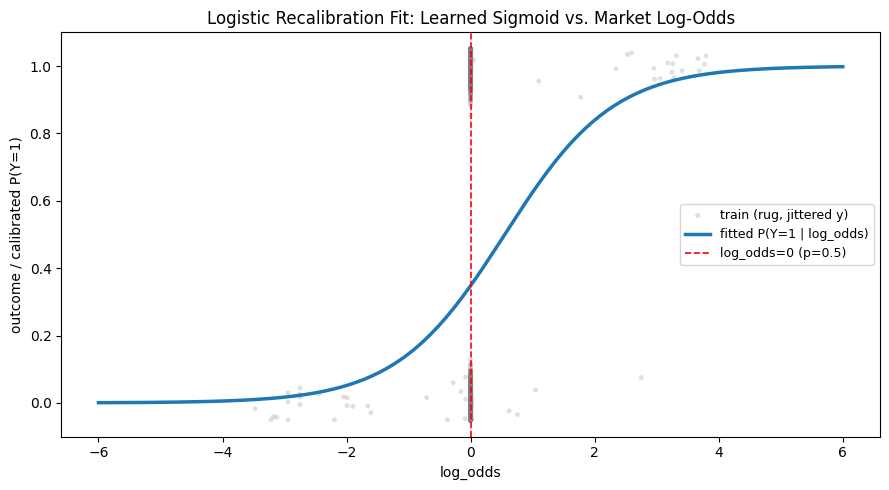

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\06_logistic_fit.png


In [3]:
import matplotlib.pyplot as plt

Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(42)
x = np.linspace(-6, 6, 200)
Xg = x.reshape(-1, 1)
p_fit = lr_model.predict_proba(Xg)[:, 1]

lo = df_train["log_odds"].astype(float).values
y = df_train["outcome"].astype(int).values
y_j = np.clip(y + rng.normal(0, 0.04, size=len(y)), -0.05, 1.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(lo, y_j, s=12, alpha=0.25, c="gray", edgecolors="none", label="train (rug, jittered y)")
ax.plot(x, p_fit, color="tab:blue", linewidth=2.5, label="fitted P(Y=1 | log_odds)")
ax.axvline(0.0, color="red", linestyle="--", linewidth=1.2, label="log_odds=0 (p=0.5)")
ax.set_xlabel("log_odds")
ax.set_ylabel("outcome / calibrated P(Y=1)")
ax.set_title("Logistic Recalibration Fit: Learned Sigmoid vs. Market Log-Odds")
ax.legend(loc="center right", fontsize=9)
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
p_out = Path(FIGURES_DIR) / "06_logistic_fit.png"
plt.savefig(p_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p_out}")

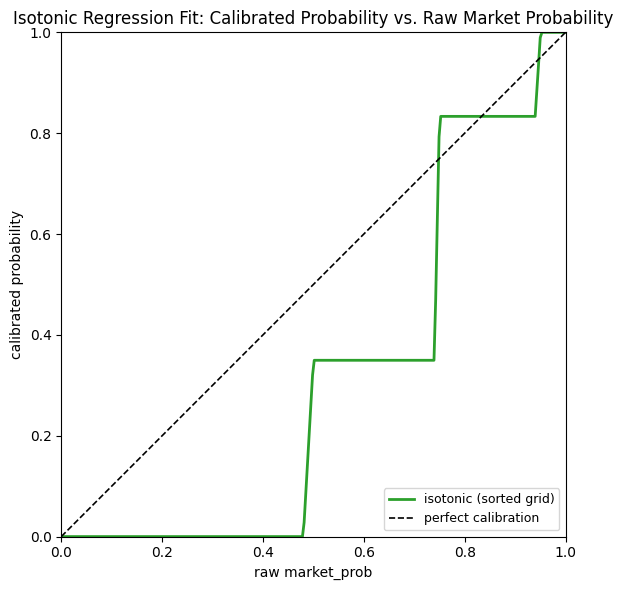

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\07_isotonic_fit.png


In [4]:
grid = np.linspace(0, 1, 300)
y_iso = iso_model.predict(grid)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(grid, y_iso, color="tab:green", linewidth=2, label="isotonic (sorted grid)")
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="perfect calibration")
ax.set_xlabel("raw market_prob")
ax.set_ylabel("calibrated probability")
ax.set_title("Isotonic Regression Fit: Calibrated Probability vs. Raw Market Probability")
ax.set_aspect("equal")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
p_out = Path(FIGURES_DIR) / "07_isotonic_fit.png"
plt.savefig(p_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p_out}")

In [5]:
import pickle

Path(POSTERIORS_DIR).mkdir(parents=True, exist_ok=True)
pred_path = Path(POSTERIORS_DIR) / "baseline_predictions.pkl"
mod_path = Path(POSTERIORS_DIR) / "baseline_models.pkl"

with open(pred_path, "wb") as f:
    pickle.dump(predictions, f)
with open(mod_path, "wb") as f:
    pickle.dump({"lr": lr_model, "iso": iso_model}, f)
print("Baseline models and predictions saved.")
print(pred_path)
print(mod_path)

Baseline models and predictions saved.
C:\Yatharth\University\MachineLEARNING\hbrm\outputs\posteriors\baseline_predictions.pkl
C:\Yatharth\University\MachineLEARNING\hbrm\outputs\posteriors\baseline_models.pkl
